# **DO NOT EDIT THIS NOTEBOOK TO AVOID CONFLICTS WHEN PUSHING/PULLING**

# **S24 Pipeline v2**

## ---------------------------------------------------------------------------------------------------------------------

## **STEP 1: Parse the .sysml (MBSE) file into a structured python object and export it to json representations**

In [1]:
from S24.pipeline.sysml_pipeline_runner import run_sysml_to_json_pipeline

result = run_sysml_to_json_pipeline(
    sysml_file="ECLIPSE_Project.sysml",
    verbose=0,
)

**AVAILABE DATA FROM RESULTS OF THE PARSING**


In [2]:
import json
# data
data = result['data']
parts = data['parts']

# METADATA
metadata = data['metadata']
print("\n[METADATA]")
print(json.dumps(metadata, indent=2))

# CONNECTIONS
connections = data['connections']
print('\nConnections Identified: \n')
for c in connections:
    print(c)

# PATHS 
paths = result['paths']
main_path = paths['main_json']
assets = paths['assets']

print(f"\nJSON FILE PATHS:\n[SUMMARY] Wrote {len(parts)} part files")
print(f"\n[WRITE] Full JSON → {main_path}")
for file_path, part in zip(assets, parts):
    print(f"[WRITE] {part['name']} → {file_path}")


[METADATA]
{
  "package": "ECLIPSE_LSP1",
  "num_parts": 6,
  "num_connections": 7,
  "validation_errors": []
}

Connections Identified: 

{'name': 'ISRUPlantToRover', 'type': 'LOXMovement', 'flow': 'LOX', 'from': {'part': 'ISRUPlant', 'port': 'ISRU_LOXPortOut'}, 'to': {'part': 'Rover', 'port': 'Rover_LOXPortInOut'}}
{'name': 'RoverToPropellantDepot', 'type': 'LOXMovement', 'flow': 'LOX', 'from': {'part': 'Rover', 'port': 'Rover_LOXPortInOut'}, 'to': {'part': 'Propellant_Depot', 'port': 'Propellant_LOXPortIn'}}
{'name': 'PowerGenToPropellant', 'type': 'PowerMovement', 'flow': 'Power', 'from': {'part': 'SolarPowerSystem', 'port': 'Power_PowerPortOutToPropellantDepot'}, 'to': {'part': 'Propellant_Depot', 'port': 'Propellant_PowerPortIn'}}
{'name': 'PowerGenToISRUPlant', 'type': 'PowerMovement', 'flow': 'Power', 'from': {'part': 'SolarPowerSystem', 'port': 'Power_PowerPortOutToISRUPlant'}, 'to': {'part': 'ISRUPlant', 'port': 'ISRU_PowerPortIn'}}
{'name': 'PowerGenToHabMod', 'type': 'Powe

## ---------------------------------------------------------------------------------------------------------------------

## **STEP 2: Node activation: Mission Network Activation**

[GRAPH] Active nodes: 6 / 6
[GRAPH] Active connections: 7 / 7

[ACTIVE CONNECTIONS]
{'name': 'ISRUPlantToRover', 'type': 'LOXMovement', 'flow': 'LOX', 'from': {'part': 'ISRUPlant', 'port': 'ISRU_LOXPortOut'}, 'to': {'part': 'Rover', 'port': 'Rover_LOXPortInOut'}}
{'name': 'RoverToPropellantDepot', 'type': 'LOXMovement', 'flow': 'LOX', 'from': {'part': 'Rover', 'port': 'Rover_LOXPortInOut'}, 'to': {'part': 'Propellant_Depot', 'port': 'Propellant_LOXPortIn'}}
{'name': 'PowerGenToPropellant', 'type': 'PowerMovement', 'flow': 'Power', 'from': {'part': 'SolarPowerSystem', 'port': 'Power_PowerPortOutToPropellantDepot'}, 'to': {'part': 'Propellant_Depot', 'port': 'Propellant_PowerPortIn'}}
{'name': 'PowerGenToISRUPlant', 'type': 'PowerMovement', 'flow': 'Power', 'from': {'part': 'SolarPowerSystem', 'port': 'Power_PowerPortOutToISRUPlant'}, 'to': {'part': 'ISRUPlant', 'port': 'ISRU_PowerPortIn'}}
{'name': 'PowerGenToHabMod', 'type': 'PowerMovement', 'flow': 'Power', 'from': {'part': 'SolarPowe

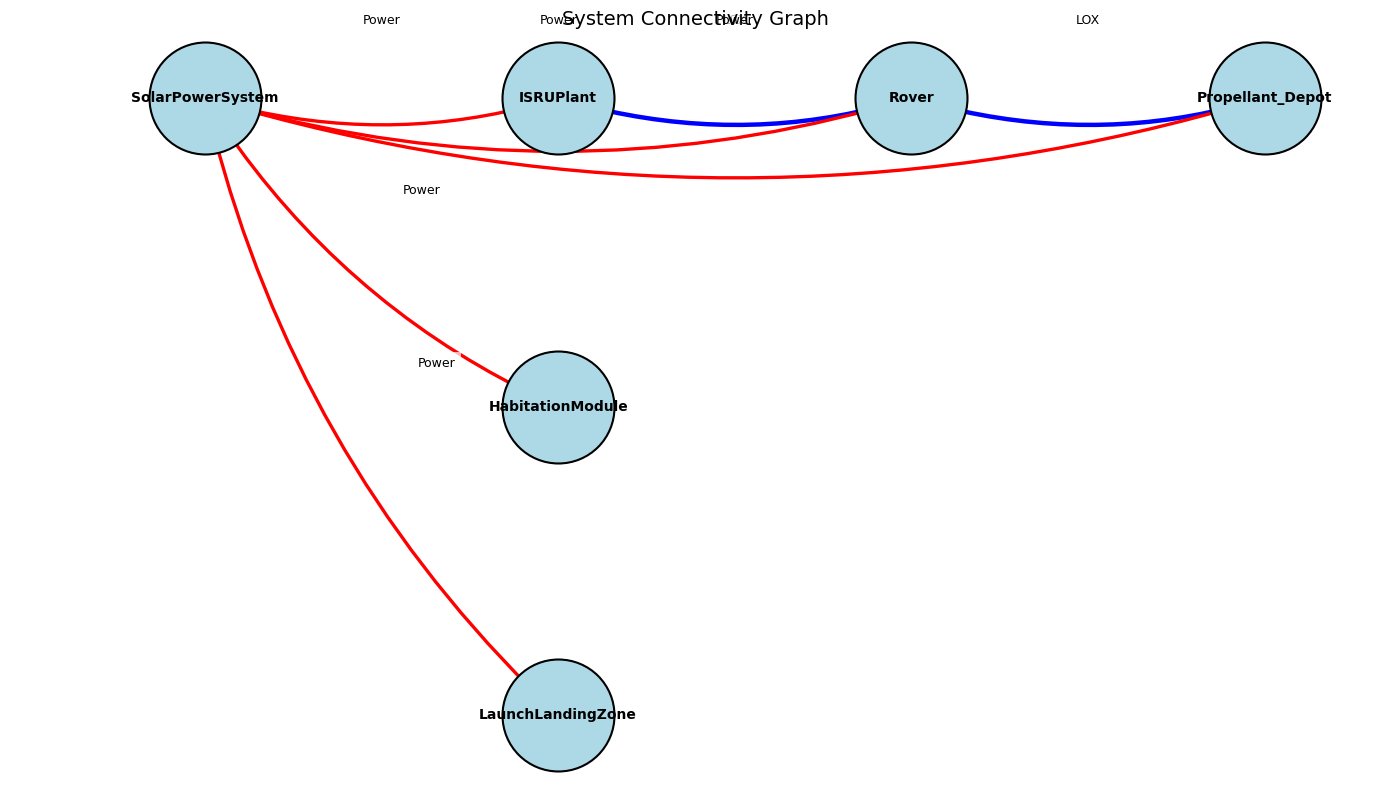

In [ ]:
from S24.pipeline.connectivity_graph_runner import run_connectivity_graph
from S24.validation.plotter import plot_system_graph # DONOTEDIT: Use only for reference and edit only in html
active_nodes = [
    "SolarPowerSystem",
    "Rover",
    "Propellant_Depot"
] 

asset_paths = result['paths']['assets']
graph = run_connectivity_graph(data=result['data'], active_nodes=None, json_asset_paths=asset_paths, verbose=1)
G = graph['graph']
plot_system_graph(G) # plot need more work to be visually correct (and directional arrows) 

**AVAILABE DATA FROM THE GRAPH**

In [4]:
active_connections = graph['connections']
active_paths = graph['asset_paths']
active_nodes = graph['active_nodes']['list']
active_nodes_no = graph['active_nodes']['count']

print("CONNECTIVITY GRAPH SUMMARY")

print(f"\n[ACTIVE NODES] ({active_nodes_no})")
for n in active_nodes:
    print(f"  - {n}")

print(f"\n[ASSET PATHS] ({len(active_paths) if active_paths else 0})")
if active_paths:
    for p in active_paths:
        print(f"  - {p}")
else:
    print("  (None)")

print(f"\n[CONNECTIONS] ({len(active_connections)})")
for c in active_connections:
    print(c)


CONNECTIVITY GRAPH SUMMARY

[ACTIVE NODES] (6)
  - HabitationModule
  - ISRUPlant
  - LaunchLandingZone
  - Propellant_Depot
  - Rover
  - SolarPowerSystem

[ASSET PATHS] (6)
  - /home/ang/Desktop/GC/main/main_branch/S24-ArchitectingLunarBases/clean_database/json/ECLIPSE_Project/assets/HabitationModule.json
  - /home/ang/Desktop/GC/main/main_branch/S24-ArchitectingLunarBases/clean_database/json/ECLIPSE_Project/assets/ISRUPlant.json
  - /home/ang/Desktop/GC/main/main_branch/S24-ArchitectingLunarBases/clean_database/json/ECLIPSE_Project/assets/LaunchLandingZone.json
  - /home/ang/Desktop/GC/main/main_branch/S24-ArchitectingLunarBases/clean_database/json/ECLIPSE_Project/assets/Propellant_Depot.json
  - /home/ang/Desktop/GC/main/main_branch/S24-ArchitectingLunarBases/clean_database/json/ECLIPSE_Project/assets/Rover.json
  - /home/ang/Desktop/GC/main/main_branch/S24-ArchitectingLunarBases/clean_database/json/ECLIPSE_Project/assets/SolarPowerSystem.json

[CONNECTIONS] (7)
{'name': 'ISRUPlant

## ---------------------------------------------------------------------------------------------------------------------

## **STEP 3: MODEL SUBMISSION**

**NOT YET IMPLEMENTED**

In [5]:
from S24.usd.model_submission import build_submission_manifest

model_manifest = build_submission_manifest(asset_paths=active_paths, verbose=2)

[PART] HabitationModule
  JSON: /home/ang/Desktop/GC/main/main_branch/S24-ArchitectingLunarBases/clean_database/json/ECLIPSE_Project/assets/HabitationModule.json
  CAD : /home/ang/Desktop/GC/main/main_branch/S24-ArchitectingLunarBases/clean_database/cad_models/habitationmodule/habitationmodule.usdc
  Pos : [0.0, 0.0, 0.0]
  Rot : [0.0, 0.0, 0.0]
  → CAD FOUND

[PART] ISRUPlant
  JSON: /home/ang/Desktop/GC/main/main_branch/S24-ArchitectingLunarBases/clean_database/json/ECLIPSE_Project/assets/ISRUPlant.json
  CAD : /home/ang/Desktop/GC/main/main_branch/S24-ArchitectingLunarBases/clean_database/cad_models/isruplant/isruplant.usdz
  Pos : [0.0, 0.0, 0.0]
  Rot : [0.0, 0.0, 0.0]
  → CAD FOUND

[PART] LaunchLandingZone
  JSON: /home/ang/Desktop/GC/main/main_branch/S24-ArchitectingLunarBases/clean_database/json/ECLIPSE_Project/assets/LaunchLandingZone.json
  CAD : /home/ang/Desktop/GC/main/main_branch/S24-ArchitectingLunarBases/clean_database/cad_models/launchlandingzone/launchlandingzone.usd

## ---------------------------------------------------------------------------------------------------------------------

## **STEP 4: Mission Tradepace Selection (DES)** 

**The DES should take active nodes, active assets paths, and slider value dictionary**

**Slider value dict and active nodes are expected to come from the user entering values on the HTML**

In [6]:
from S24.DES_pipeline_version import run_scenario

slider_value_dict = {
    "Num_Regolith_Rovers": 3,
    "Num_ISRU_Plants": 2,
    "Regolith_Haul_Distance": 1, #km
    "LOX_Haul_Distance": 1, #km
    "Rover_Energy_Consumption": 0.00034, #kWh/km/kg, Energy Per Kilometer Per Kilogram of Payload, supposed to replace the "Rover discharge rate" slider value
    "Rover_Travel_Time": 5, #hr/km
    "ISRU_Plant_Processing_Rate": 1600, #kg/hr
    "LOX_Transport_Threshold": 100, #kg, the amount of LOX at which the LOX rover will take the LOX at the ISRU plant and transport it to the launch and landing zone.
}

run_scenario(slider_value_dict)

ISRU Processing Plant with Full Infrastructure
The total energy consumed by Regolith Cargo Rover 1 is 1.36 kWh.
The total energy consumed by Regolith Cargo Rover 2 is 1.36 kWh.
The total energy consumed by Regolith Cargo Rover 3 is 1.36 kWh.
[5.00 hr] Rover delivered 4000 kg regolith
The total energy consumed by Regolith Cargo Rover 1 is 2.72 kWh.
[5.00 hr] Rover delivered 4000 kg regolith
The total energy consumed by Regolith Cargo Rover 2 is 2.72 kWh.
[5.00 hr] Rover delivered 4000 kg regolith
The total energy consumed by Regolith Cargo Rover 3 is 2.72 kWh.
[7.50 hr] ISRU Plant produced 10.11160806802452 kg of LOX from 4000 kg of Regolith using 237.2406742425153 kWh of Energy. There is now 10.11160806802452 kg of LOX stored, and 243.5098712446905 kWh has been consumed.
[7.50 hr] ISRU Plant produced 10.11160806802452 kg of LOX from 4000 kg of Regolith using 237.2406742425153 kWh of Energy. There is now 10.11160806802452 kg of LOX stored, and 243.5098712446905 kWh has been consumed.
[1

## ---------------------------------------------------------------------------------------------------------------------

## **STEP 5: Simulator (OpenUSD+OMNIVERSE)** 

**NOT YET IMPLEMENTED**

In [7]:
# sys.path.insert(0, "/home/ang/usd_ang/lib/python")
# os.environ["LD_LIBRARY_PATH"] = "/home/ang/usd_ang/lib"

In [8]:
# from S24.jsonio import VettingProc

# vetting = VettingProc(source=str(JSON_FILE))
# vetted_parts = vetting.by_name

# list(vetted_parts.keys())

In [9]:
# from S24.usd import USDBuilder

# builder = USDBuilder(
#     vetted_parts,
#     overwrite=True,
#     use_paths_from_vetted=False
# )

# outputs = builder.build_all_parts()
# outputs

# scene_path = builder.write_assembly_scene(
#     root_name="HabitationModule",
#     include_root_as_instance=True,
#     instanceable=False,
#     debug_refs=True
# )

# scene_path